<a href="https://colab.research.google.com/github/roeytoo111/deep_learning/blob/master/t05_Sequence_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$
\newcommand{\bb}[1]{\boldsymbol{#1}}
$$

# Deep Learning - Tutorial 5: Sequence Models


#### Agenda
* Recurrent Neural networks


In [ ]:
!pip install torchviz

In [ ]:
# Setup
%matplotlib inline
import os
import sys
# import time
import torch
import warnings
warnings.simplefilter("ignore")

# pytorch
import torchviz
import torch.nn as nn

import torch.nn.functional as f
import torch.optim as optim

import numpy as np

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Intuition


How can we model a dynamical system?

<br>
    <center><img src="https://raw.githubusercontent.com/mkimhi/cs3600-tutorials/bff05457bd30d5c798a6ec3bbc59d2ff23453eb2/T4/resources/rnn.gif" width="600" /></center>


E.g., a linear system such as

$$\vec{y}_t = a_0 + a_1 \vec{y}_{t-1}+\dots+a_P \vec{y}_{t-P} + b_0 \vec{x}_t+\dots+b_{t-Q}\vec{x}_{t-Q}$$

Many use cases and examples: signal processing, text translation, sentiment analysis, scene classification in video, etc.

<br>

<center><img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fvictorzhou.com%2Fstatic%2F2a37bd4e9b12bcc19e045eaf22fea4e5%2F03346%2Frnns.jpg&f=1&nofb=1&ipt=86b8ae9ffa3a53d0ae49ecac5007708a1f32328d8b31f468c8522ea0dd900e1e&ipo=images" width="800" /></center>

<br>

## Recurrent Neural Networks

A recurrent neural network (RNN) is a type of artificial neural network which uses sequential data or time series data.

They are distinguished by their "memory" as they take information from prior inputs to influence the current input and output.

While traditional deep neural networks assume that inputs and outputs are independent of each other, the output of recurrent neural networks depend on the prior elements within the sequence.

<br>

<center><img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Ftse2.mm.bing.net%2Fth%3Fid%3DOIP.giDURXThL3EzU4MgMDC7ywHaDu%26pid%3DApi&f=1&ipt=cc7cda92ab730d0f450a28a22fac89c020eadff5ea457581ddb3dfe74dc58f20&ipo=images" width="600" /></center>

<br>

**What is RNN?**
* Recurrent Neural Network is a generalization of feed forward neural network that has an internal memory.
* RNN is recurrent in nature as it performs the same function for every input of data while the output of the current input depends on the past one computation.
* For making a decision, it considers the current input and the output that it has learned from the previous input.
* Unlike feed forward neural networks, RNNs can use their internal state (memory) to process sequences of inputs.

1. **Best suited for sequential data**

    It can handle arbitrary input / output lengths.
    This makes RNNs best suited for predicting what comes next in a sequence of words.
    RNN that is trained to translate text might learn that dog ” should be translated differently if preceded by the word hot.

2. **RNN has internal memory**
    
    RNN has memory capabilities. It memorizes previous data. Output from previous step is fed as input to the current step creating a feedback loop.
    So, it calculates its current state using set of current input and the previous state. In this way, the information cycles through a loop.
    We can say that RNN has two inputs, the present and the recent past.

3. **Shared parameters**

    Another distinguishing characteristic of recurrent networks is that they share parameters across each layer of the network.
    While feedforward networks have different weights across each node, recurrent neural networks share the same weight parameter within each layer of the network.

  


### Recurrent Layers

An RNN layer is similar to a regular FC layer, but it has two inputs:
- Current sample, ${x}_t$.
- Previous **state**, ${h}_{t-1}$.

and it produces two outputs which depend on both:
- Current layer output, ${y}_t$.
- Current **state**, ${h}_{t}$.


<br>

<center><img src="https://www.simplilearn.com/ice9/free_resources_article_thumb/Fully_connected_Recurrent_Neural_Network1.png" width="700" /></center>

<br>

Crucially,
* The layer itself is not time-dependent (but is parametrized).
* The same layer (function) is applied at successive time steps, propagating the hidden state.


A basic RNN can be defined as follows.

$$
\begin{align}
\forall t \geq 0:\\
{h}_t &= \varphi_h\left( {W}_{hh} {h}_{t-1} + {W}_{xh} {x}_t + {b}_h\right) \\
{y}_t &= \varphi_y\left({W}_{hy}{h}_t + {b}_y \right)
\end{align}
$$

where,
- ${x}_t$ is the input at time $t$.
- ${h}_{t-1}$ is the **hidden state** of a fixed dimension.
- ${y}_t$ is the output at time $t$.
- ${W}_{hh}$, ${W}_{xh}$, ${W}_{hy}$, ${b}_h$ and ${b}_y$ are the model weights and biases.
- $\varphi_h$ and $\varphi_y$ are some non-linear functions. In many cases $\varphi_y$ is not used.

#### Modeling time-dependence


If we imagine unrolling a single RNN layer through time

<br>

<center><img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.mdpi.com%2Fsensors%2Fsensors-22-08112%2Farticle_deploy%2Fhtml%2Fimages%2Fsensors-22-08112-g010.png&f=1&nofb=1&ipt=26aec3aca667963cd80b1caa2bd42c7f334ec30a15d411fbd12fec04fa8ec0fc" width="600" /></center>

<br>

We can see how late outputs can now be influenced by early inputs, through the hidden state.

RNN models are very flexible in terms of input and output meaning.

Common applications include image captioning, sentiment analysis, machine translation and signal processing.



How would **backpropagation** work, though?

<br>
<center><img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fmiro.medium.com%2Fmax%2F1280%2F1*zfqlhCEQRY-70SCig3-ZNw.jpeg&f=1&nofb=1&ipt=bdbc35c2082caddc3d365bcb68d9b5bdaae508e674e477902b37817e21a863c2&ipo=images" width="600" /></center>
<br>


  1. Calculated loss from each output and accumulate
  2. Calculate Gradient of loss w.r.t. each parameter at each timestep
  3. For each parameter, accumulate gradients from all timesteps


This is known as **Backpropagation through time**, or BPTT. (see formula in lecture slides).

But how far back do we go? What's the limiting factor?

We're limited in depth by vanishing and exploding gradients controlled by the eigenvalues of W.

Solutions:
1. Limit the number of timesteps involved in the backpropagation. This is known as *Truncated backpropagation through time*, or TBPTT.

2. *Gradient Clipping* - look at the norm of the gradients and when they exceed some threshold clip it down.



### Multi-layered (deep) RNN

RNNs layers can be stacked to build a deep RNN model.

* As with MLPs, adding depth allows us to model intricate hierarchical features.
* However, now we also have a time dimension which makes the representation time-dependent.

<br>

<center><img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fbbs-img.huaweicloud.com%2Fblogs%2Fimg%2Frnn-1.PNG&f=1&nofb=1&ipt=e6fd295921ee27aa4ef16076d5b4bd83c9ec116d0bc8149a1222b2a203c4cb5d&ipo=images" width="900" /></center>

<br>



## RNN Implementation



In PyTorch you have an implemented [RNN class](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)

```
torch.nn.RNN(self, input_size, hidden_size, num_layers=1, nonlinearity='tanh', bias=True, batch_first=False, dropout=0.0, bidirectional=False, device=None, dtype=None)
```


Parameters

* **input_size**: The number of expected features in the input x.
* **hidden_size**: The number of features in the hidden state h.
* **num_layers**: Number of recurrent layers. E.g., setting `num_layers=2` would mean stacking two RNNs together to form a stacked RNN, with the second RNN taking in outputs of the first RNN and computing the final results. Default: 1.
* **nonlinearity**: The non-linearity to use, either 'tanh' or 'relu'. Default: 'tanh'.
* **bias**: If False, then the layer does not use bias weights b_ih and b_hh. Default: True.
* **batch_first**: If True, then the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature).
* **dropout**: If non-zero, introduces a Dropout layer on the outputs of each RNN layer except the last layer, with dropout probability equal to dropout. Default: 0.
* **bidirectional**: If True, becomes a bidirectional RNN. Default: False.


**inputs** input and h_0

**outputs** output and h_n

Input to RNN:

  *  `input` is of size `(seq_len, batch_size, input_size)` representing a batch of sequences, if `batch_first=True` then `(batch_size, seq_len, input_size)`.
  *  `h0` is the initial hidden state of size `(num_layers, batch_size, hidden_size)`. if bidirectional then num_layers*directions.

Output from RNN:

  *  `output` contains hidden states for all time steps of all sequences. Its size is `(seq_len, batch_size, hidden_size)`. if `batch_first=True`, then batch_size comes first.
  *  `hn` contains the final hidden state for the last time step, for all layers. Its size is `(num_layers, batch_size, hidden_size)`.

In [ ]:
batch_size = 2 # in our example: Number of sentences
seq_len = 3 # in our example: 3 words per sentence
embedding_dim = 4 #in our example: Each word is a vector of 3 numbers [x, y, z]

# Input: (seq, batch, Feature) -> ( 3 Words, 2 sen, 4 Embedding Values)
input = torch.randn(seq_len, batch_size , embedding_dim)

print('input size', input.size())
print(input[0])

input size torch.Size([3, 2, 4])
tensor([[ 1.4353, -1.2612, -0.8627,  0.6753],
        [-2.5371, -0.1290, -0.2794,  0.3718]])


In [ ]:
hidden_dim = 5 # A vector of 5 numbers representing history/hidden of the wanted output

# h0 represents the state before reading the first word (usually zeros or random noise).
# Shape is ALWAYS (Num_Layers * Num_Directions, Batch, Hidden_Size)
# h0 represents the "Prior Knowledge"

h0 = torch.randn(7, batch_size, hidden_dim)
print('h0 size', h0.size())
print(h0[0])

h0 size torch.Size([7, 2, 5])
tensor([[ 0.0843, -0.6250, -1.2388, -0.1269,  0.2143],
        [-2.0381, -0.5490,  0.9450,  1.2721, -0.1244]])


In [ ]:
rnn = nn.RNN(
    input_size = embedding_dim, # =4
    hidden_size = hidden_dim, # =5
    num_layers = 7)
print(rnn)

RNN(4, 5, num_layers=7)


In [ ]:
output, hn = rnn(input, h0)

# Output tensor dimensions:
# batch_size = 2: Same as input batch size
# seq_len = 3: Number of time steps (same as input)
# hidden_size = 5: Number of hidden units (same as defined in the RNN)
print('output size', output.size())  # Expected: torch.Size([3, 2, 5])

# hn tensor dimensions:
# num_layers = 7: Number of layers in the RNN
# batch_size = 2: Number of sequences in the batch
# hidden_size = 5: Number of hidden units (same as defined in the RNN)
print('hn size', hn.size())  # Expected: torch.Size([7, 2, 5])

output size torch.Size([3, 2, 5])
hn size torch.Size([7, 2, 5])


Input to RNN:

  *  `input` is of size `(batch_size, seq_len, input_size)` representing a batch of sequences.
  *  `h0` is the initial hidden state of size `(num_layers, seq_len, hidden_size)`.

Output from RNN:

  *  `output` contains hidden states for all time steps of all sequences. Its size is `(batch_size, seq_len, hidden_size)`.
  *  `hn` contains the final hidden state for the last time step, for all layers. Its size is `(num_layers, batch_size, hidden_size)`.

### RNN from scratch

Reminder of the equations

$$ h_t = \phi_h( W_x \cdot x_t + W_h \cdot h_{t-1} + b_h ) $$

$$ y_t = \phi_y(W_y \cdot h_t + b_y) $$

In [ ]:
class RNNLayer(nn.Module):
  def __init__(self, in_dim, h_dim, out_dim, phi_h=torch.tanh, phi_y=torch.sigmoid):
    super().__init__()
    # Store activation functions for hidden and output layers
    self.phi_h, self.phi_y = phi_h, phi_y

    self.fc_xh = nn.Linear(in_dim, h_dim, bias=False) # Linear layer for input-to-hidden transformation
    self.fc_hh = nn.Linear(h_dim, h_dim, bias=True) # Linear layer for hidden-to-hidden transformation
    self.fc_hy = nn.Linear(h_dim, out_dim, bias=True) # Linear layer for hidden-to-output transformation

  def forward(self, xt, h_prev=None):
    if h_prev is None: # If no previous hidden state is provided, initialize with zeros
      h_prev = torch.zeros(xt.shape[0], self.fc_hh.in_features)

    # Compute the new hidden state: ht = phi_h(W_xh * xt + W_hh * h_prev + b_hh)
    ht = self.phi_h(self.fc_xh(xt) + self.fc_hh(h_prev))

    # Compute the output: yt = W_hy * ht + b_hy
    yt = self.fc_hy(ht)

    # Apply activation function for the output, if defined
    if self.phi_y is not None:
      yt = self.phi_y(yt)

    # Return the output and updated hidden state
    return yt, ht

In [ ]:
# model initilization

N = 3 # batch size
in_dim, h_dim, out_dim = 1024, 10, 1

rnn2 = RNNLayer(in_dim, h_dim, out_dim)
rnn2

RNNLayer(
  (fc_xh): Linear(in_features=1024, out_features=10, bias=False)
  (fc_hh): Linear(in_features=10, out_features=10, bias=True)
  (fc_hy): Linear(in_features=10, out_features=1, bias=True)
)

And, manually run a few times.

In [ ]:
# t=1
x1 = torch.randn(N, in_dim, requires_grad=True) # requiring grad just for torchviz
y1, h1 = rnn2(x1)
print(f'y1 ({tuple(y1.shape)}):\n{y1}')
print(f'h1 ({tuple(h1.shape)}):\n{h1}\n')

# t=2
x2 = torch.randn(N, in_dim, requires_grad=True)
y2, h2 = rnn2(x2, h1)
print(f'y2 ({tuple(y2.shape)}):\n{y2}')
print(f'h2 ({tuple(h2.shape)}):\n{h2}\n')

y1 ((3, 1)):
tensor([[0.5039],
        [0.3703],
        [0.3333]], grad_fn=<SigmoidBackward0>)
h1 ((3, 10)):
tensor([[ 0.0266, -0.3040,  0.1245, -0.7759, -0.3636, -0.5630,  0.3789, -0.2640,
         -0.0784, -0.4073],
        [ 0.2359, -0.4008,  0.3725,  0.0675,  0.7261, -0.6435, -0.6365,  0.0546,
          0.6488,  0.5017],
        [ 0.4838, -0.4514, -0.3089,  0.7794,  0.3610,  0.0195, -0.3966,  0.2720,
          0.2652,  0.7534]], grad_fn=<TanhBackward0>)

y2 ((3, 1)):
tensor([[0.4566],
        [0.4581],
        [0.4227]], grad_fn=<SigmoidBackward0>)
h2 ((3, 10)):
tensor([[ 0.2167, -0.4242, -0.5736,  0.3588, -0.1905,  0.3946, -0.6557,  0.2093,
         -0.0023, -0.0087],
        [ 0.2038, -0.1968,  0.6735, -0.7184,  0.0273,  0.2449,  0.0277,  0.1531,
          0.8953,  0.8268],
        [ 0.6531,  0.0520,  0.2553, -0.3782, -0.0887, -0.1274, -0.2301,  0.0714,
          0.5413,  0.2053]], grad_fn=<TanhBackward0>)



We can visuallize the computational graph and see what happened when we used the same RNN block twice by looking at the graph from y1 and y2.

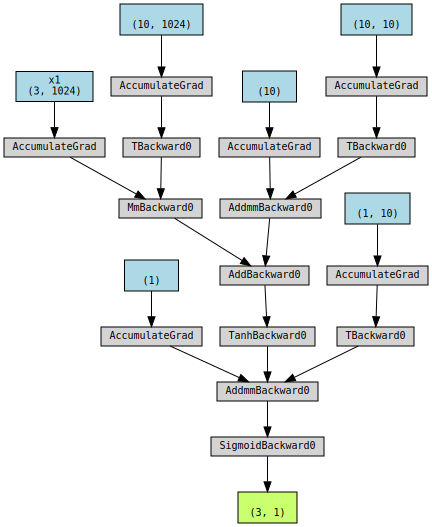

In [ ]:
torchviz.make_dot(
    y1, # Note: Change here to y2 to see the fullly unrolled graph!
    params=dict(list(rnn.named_parameters()) + [('x1', x1), ('x2', x2)])
)

### Example: RNN Next Character Prediction





First, we'll define the sentences that we want our model to output when fed with the first word or the first few characters.

Then we'll create a dictionary out of all the characters that we have in the sentences and map them to an integer. This will allow us to convert our input characters to their respective integers (char2int) and vice versa (int2char).


In [ ]:
text = ['hey how are you',
        'good i am fine',
        'have a nice day']

# Join all the sentences together and extract the unique characters from the combined sentences
chars = set(''.join(text))

# Creating a dictionary that maps integers to the characters
int2char = dict(enumerate(chars))

# Creating another dictionary that maps characters to integers
char2int = {char: ind for ind, char in int2char.items()}

In [ ]:
print(chars)

{' ', 'n', 'a', 'r', 'g', 'y', 'o', 'u', 'h', 'd', 'w', 'v', 'f', 'e', 'i', 'm', 'c'}


In [ ]:
print(int2char)

{0: ' ', 1: 'n', 2: 'a', 3: 'r', 4: 'g', 5: 'y', 6: 'o', 7: 'u', 8: 'h', 9: 'd', 10: 'w', 11: 'v', 12: 'f', 13: 'e', 14: 'i', 15: 'm', 16: 'c'}


In [ ]:
print(char2int)

{' ': 0, 'n': 1, 'a': 2, 'r': 3, 'g': 4, 'y': 5, 'o': 6, 'u': 7, 'h': 8, 'd': 9, 'w': 10, 'v': 11, 'f': 12, 'e': 13, 'i': 14, 'm': 15, 'c': 16}




Next, we'll be padding our input sentences to ensure that all the sentences are of the sample length. While RNNs are typically able to take in variably sized inputs, we will usually want to feed training data in batches to speed up the training process. In order to used batches to train on our data, we'll need to ensure that each sequence within the input data are of equal size.

Therefore, in most cases, padding can be done by filling up sequences that are too short with 0 values and trimming sequences that are too long. In our case, we'll be finding the length of the longest sequence and padding the rest of the sentences with blank spaces to match that length.


In [ ]:
maxlen = len(max(text, key=len))
print("The longest string has {} characters".format(maxlen))

The longest string has 15 characters


In [ ]:
# Padding

# A simple loop that loops through the list of sentences and adds a ' ' whitespace until the length of the sentence matches
# the length of the longest sentence
for i in range(len(text)):
  while len(text[i])<maxlen:
    text[i] += ' '

In [ ]:
text

['hey how are you', 'good i am fine ', 'have a nice day']



As we're going to predict the next character in the sequence at each time step, we'll have to divide each sentence into

* Input data
    * The last input character should be excluded as it does not need to be fed into the model
* Target/Ground Truth Label
    * One time-step ahead of the Input data as this will be the "correct answer" for the model at each time step corresponding to the input data



In [ ]:
# Creating lists that will hold our input and target sequences
input_seq = []
target_seq = []

for i in range(len(text)):
    # Remove last character for input sequence
    input_seq.append(text[i][:-1])

    # Remove firsts character for target sequence
    target_seq.append(text[i][1:])
    print("Input Sequence: {}\nTarget Sequence: {}".format(input_seq[i], target_seq[i]))

Input Sequence: hey how are yo
Target Sequence: ey how are you
Input Sequence: good i am fine
Target Sequence: ood i am fine 
Input Sequence: have a nice da
Target Sequence: ave a nice day


Now we can convert our input and target sequences to sequences of integers instead of characters by mapping them using the dictionaries we created above. This will allow us to one-hot-encode our input sequence subsequently.

In [ ]:
for i in range(len(text)):
  input_seq[i] = [char2int[character] for character in input_seq[i]]
  target_seq[i] = [char2int[character] for character in target_seq[i]]

In [ ]:
input_seq

[[8, 13, 5, 0, 8, 6, 10, 0, 2, 3, 13, 0, 5, 6],
 [4, 6, 6, 9, 0, 14, 0, 2, 15, 0, 12, 14, 1, 13],
 [8, 2, 11, 13, 0, 2, 0, 1, 14, 16, 13, 0, 9, 2]]



Before encoding our input sequence into one-hot vectors, we'll define 3 key variables:

* dict_size: The number of unique characters that we have in our text
    * This will determine the one-hot vector size as each character will have an assigned index in that vector
* seq_len: The length of the sequences that we're feeding into the model
    * As we standardised the length of all our sentences to be equal to the longest sentences, this value will be the max length - 1 as we removed the last character input as well
* batch_size: The number of sentences that we defined and are going to feed into the model as a batch



In [ ]:
dict_size = len(char2int)
seq_len = maxlen - 1
batch_size = len(text)

print("dict_size ", dict_size)
print("seq_len ", seq_len)
print("batch_size ", batch_size)

dict_size  17
seq_len  14
batch_size  3


In [ ]:
def one_hot_encode(sequence, dict_size, seq_len, batch_size):
  # Creating a multi-dimensional array of zeros with the desired output shape
  features = np.zeros((batch_size, seq_len, dict_size), dtype=np.float32)

  # Replacing the 0 at the relevant character index with a 1 to represent that character
  for i in range(batch_size):
    for u in range(seq_len):
      features[i, u, sequence[i][u]] = 1
  return features



We also defined a helper function that creates arrays of zeros for each character and replaces the corresponding character index with a **1**.


In [ ]:
input_seq = one_hot_encode(input_seq, dict_size, seq_len, batch_size)
print("Input shape: {} --> (Batch Size, Sequence Length, One-Hot Encoding Size)".format(input_seq.shape))

Input shape: (3, 14, 17) --> (Batch Size, Sequence Length, One-Hot Encoding Size)


Since we're done with all the data pre-processing, we can now move the data from numpy arrays to PyTorch's very own data structure - **Torch Tensors**

In [ ]:
input_seq = torch.from_numpy(input_seq)
target_seq = torch.Tensor(target_seq)

In [ ]:
input_seq

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.

In [ ]:
target_seq

tensor([[13.,  5.,  0.,  8.,  6., 10.,  0.,  2.,  3., 13.,  0.,  5.,  6.,  7.],
        [ 6.,  6.,  9.,  0., 14.,  0.,  2., 15.,  0., 12., 14.,  1., 13.,  0.],
        [ 2., 11., 13.,  0.,  2.,  0.,  1., 14., 16., 13.,  0.,  9.,  2.,  5.]])



Now we'll be defining the model using the Torch library, and this is where you can add or remove layers, be it fully connected layers, convolutational layers, RNN layers, LSTM layers, and many more. In this example, we'll be using the basic `nn.rnn` to demonstrate a simple example of how RNNs can be used.

Before we start building the model, let's use a build in feature in PyTorch to check the device we're running on (CPU or GPU).


In [ ]:
# torch.cuda.is_available() checks and returns a Boolean True if a GPU is available, else it'll return False
is_cuda = torch.cuda.is_available()

# If we have a GPU available, we'll set our device to GPU. We'll use this device variable later in our code.
if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")

GPU not available, CPU used




To start building our own neural network model, we can define a class that inherits PyTorch’s base class (`nn.module`) for all neural network modules. After doing so, we can start defining some variables and also the layers for our model under the constructor. For this model, we’ll only be using 1 layer of RNN followed by a fully connected layer. The fully connected layer will be in-charge of converting the RNN output to our desired output shape.

We’ll also have to define the forward pass function under `forward()` as a class method. The order the forward function is sequentially executed, therefore we’ll have to pass the inputs and the zero-initialized hidden state through the RNN layer first, before passing the RNN outputs to the fully-connected layer. Note that we are using the layers that we defined in the constructor.

The last method that we have to define is the method that we called earlier to initialize the hidden state - `init_hidden()`. This basically creates a tensor of zeros in the shape of our hidden states.


In [ ]:
class Model(nn.Module):
    def __init__(self, input_size, output_size, hidden_dim, n_layers):
        super(Model, self).__init__()

        # Defining some parameters
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        #Defining the layers
        # RNN Layer
        self.rnn = nn.RNN(input_size, hidden_dim, n_layers, batch_first=True)
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_size)

    def forward(self, x):

        batch_size = x.size(0)

        #Initializing hidden state for first input using method defined below
        hidden = self.init_hidden(batch_size)

        # Passing in the input and hidden state into the model and obtaining outputs
        out, hidden = self.rnn(x, hidden)
        # out shape: [3, 14, 12]  (Batch, Seq_Len, Hidden_Dim)

        # Reshaping the outputs such that it can be fit into the fully connected layer
        # (batch_size, seq_len, hidden_dim) -> (batch_size * seq_len, hidden_dim)
        out = out.contiguous().view(-1, self.hidden_dim)

        out = self.fc(out)
        # out: Contains the predictions or intermediate features for each time step in the sequence,
        # ready for further processing (e.g., classification or regression).
        # hidden: Encodes the final state of the sequence.
        return out, hidden

    def init_hidden(self, batch_size):
        # This method generates the first hidden state of zeros which we'll use in the forward pass
        hidden = torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)
         # We'll send the tensor holding the hidden state to the device we specified earlier as well
        return hidden



After defining the model above, we'll have to instantiate the model with the relevant parameters and define our hyperparamters as well. The hyperparameters we're defining below are:

* `n_epochs`: Number of Epochs --> This refers to the number of times our model will go through the entire training dataset
* `lr`: Learning Rate --> This affects the rate at which our model updates the weights in the cells each time backpropogation is done
    * A smaller learning rate means that the model changes the values of the weight with a smaller magnitude
    * A larger learning rate means that the weights are updated to a larger extent for each time step

Similar to other neural networks, we have to define the optimizer and loss function as well. We’ll be using CrossEntropyLoss as the final output is basically a classification task.


In [ ]:
# Instantiate the model with hyperparameters
model = Model(input_size=dict_size, output_size=dict_size, hidden_dim=12, n_layers=1)
# We'll also set the model to the device that we defined earlier (default is CPU)
model = model.to(device)

# Define hyperparameters
n_epochs = 100
lr=0.01

# Define Loss, Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

Now we can begin our training! As we only have a few sentences, this training process is very fast. However, as we progress, larger datasets and deeper models mean that the input data is much larger and the number of parameters within the model that we have to compute is much more.

In [ ]:
# Training Run
input_seq = input_seq.to(device)
target_seq = target_seq.to(device)

for epoch in range(1, n_epochs + 1):

    optimizer.zero_grad() # Clears existing gradients from previous epoch
    output, hidden = model(input_seq)
    output = output.to(device)

    loss = criterion(output, target_seq.view(-1).long())
    loss.backward() # Does backpropagation and calculates gradients
    optimizer.step() # Updates the weights accordingly

    if epoch%10 == 0:
        print('Epoch: {}/{}.............'.format(epoch, n_epochs), end=' ')
        print("Loss: {:.4f}".format(loss.item()))

Epoch: 10/100............. Loss: 2.4132
Epoch: 20/100............. Loss: 2.1941
Epoch: 30/100............. Loss: 1.8320
Epoch: 40/100............. Loss: 1.3924
Epoch: 50/100............. Loss: 0.9785
Epoch: 60/100............. Loss: 0.6656
Epoch: 70/100............. Loss: 0.4477
Epoch: 80/100............. Loss: 0.3125
Epoch: 90/100............. Loss: 0.2278
Epoch: 100/100............. Loss: 0.1732


Let’s test our model now and see what kind of output we will get. Before that, let’s define some helper function to convert our model output back to text.

In [ ]:
def predict(model, character):
    # One-hot encoding our input to fit into the model
    character = np.array([[char2int[c] for c in character]])
    character = one_hot_encode(character, dict_size, character.shape[1], 1)
    character = torch.from_numpy(character)
    character = character.to(device)

    out, hidden = model(character)

    prob = nn.functional.softmax(out[-1], dim=0).data
    # Taking the class with the highest probability score from the output
    char_ind = torch.max(prob, dim=0)[1].item()

    return int2char[char_ind], hidden

In [ ]:
def sample(model, out_len, start='hey'):
  model.eval() # eval mode
  start = start.lower()
  # First off, run through the starting characters
  chars = [ch for ch in start]
  size = out_len - len(chars)
  # Now pass in the previous characters and get a new one
  for ii in range(size):
      char, h = predict(model, chars)
      chars.append(char)
      print(chars)

  return ''.join(chars)

In [ ]:
sample(model, 20, 'fi')

['f', 'i', 'n']
['f', 'i', 'n', 'e']
['f', 'i', 'n', 'e', ' ']
['f', 'i', 'n', 'e', ' ', 'y']
['f', 'i', 'n', 'e', ' ', 'y', ' ']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c', 'e']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c', 'e', ' ']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c', 'e', ' ', 'd']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c', 'e', ' ', 'd', 'a']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c', 'e', ' ', 'd', 'a', 'y']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c', 'e', ' ', 'd', 'a', 'y', ' ']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c', 'e', ' ', 'd', 'a', 'y', ' ', 'f']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c', 'e', ' ', 'd', 'a', 'y', ' ', 'f', 'i']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c', 'e', ' ', 'd', 'a', 'y', ' ', 'f', 'i', 'n']
['f', 'i', 'n', 'e', ' ', 'y', ' ', 'i', 'i', 'c

'fine y iice day fine'

As we can see, the model is able to come up with the sentence ‘good i am fine ‘ if we feed it with the words ‘good’, achieving what we intended for it to do!

## LSTM and GRU

We will talk about **Long Short term Memory (LSTM)** and **Gated Recurrent Unit (GRU)**. both are a type of recurrent cell that tries to preserve long term information.

### LSTM



The idea of LSTM was presented back in 1997, but flourished in the age of deep learning.

The name "long short-term memory" comes from the way LSTMs handle information. Regular recurrent neural networks (RNNs) have two types of memory: **long-term memory**, which is stored in the weights of the network and changes slowly as the model learns, and **short-term memory**, which comes from the activations that pass between nodes as the network processes input.

LSTMs add something new: a memory cell, which acts like a storage unit for information. This memory cell can decide what to keep, what to forget, and what to update, thanks to special mechanisms called gates. This allows the LSTM to hold on to important information for a longer time, making it better at understanding sequences where earlier context matters.

<br>

The cell has `memory` or `context` that's based on the `state` of basic RNN and on 3 main gates:

- Input gate: decides when to read data into the cell.
- Output gate: outputs the entries from the cell.
- Forget gate: a mechanism to reset the content of the cell.
These gates learn which information is relevant to forget or remember during the training process. The gates contain a non-linear activision function (sigmoid).



* we denote the input  $X_t $ at timestemp $t$ and the hidden state of the previous time step is $H_{t−1}$.

<br>
<center><img src="https://raw.githubusercontent.com/mkimhi/cs3600-tutorials/main/T4/resources/LSTM.PNG" width="800" /></center>


- **Forget gate**: $$ F_t = \sigma(X_tW_{xf} +H_{t-1}W_{hf} +b_f), $$
- **Input gate**: $$ I_t = \sigma(X_tW_{xi} +H_{t-1}W_{hi} +b_i),$$
- **Output gate**: $$ O_t = \sigma(X_tW_{xo} +H_{t-1}W_{ho} +b_o), $$

- **candidate memory**:$$ \tilde{C}_t = \text{tanh}(X_tW_{xc} +H_{t-1}W_{hc} +b_c)$$

- **memory / context**: $$ C_t = F_t \odot C_{t-1} + I_{t} \odot \tilde{C}_t$$

- **hidden state**: $$ H_t = O_t \odot \text{tanh}(C_t)$$


as you can see, we save 2 diffrent states, `hidden` and `context` (and of course it's not mentioned, but we have the output as well).

This helps with vanishing gradients, yet a big set of weights is added to the simple RNN.

You can read more and look at an implementation from scratch of LSTM [here](https://d2l.ai/chapter_recurrent-modern/lstm.html).

#### LSTM in PyTorch

LSTM has a ready to use implementation in pytorch using the class `torch.nn.LSTM(...)` which applies a multi-layer long short-term memory to an input sequence. Read about the different parameters [here](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html).

```
class
torch.nn.LSTM(self, input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0.0, bidirectional=False, proj_size=0, device=None, dtype=None)
```

**inputs**:
- ***input***: a tensor containing the features of the input sequence.
    - Dimensionality: `(seq_len, batch_size, input_size)` if `batch_first=False` (default)
    - or `(batch_size, seq_len, input_size)` if `batch_first=True`.
- ***(h_0, c_0)***: where h_0 is the initial hidden state for each element and c_0 is the initial cell state for each element.
    - Neutral Initialization: Initializing with zeros ensures that the LSTM doesn’t start with any bias toward specific patterns. This allows it to learn directly from the input sequence.

    - Dimensionality: The shape of these tensors depends on the LSTM configuration:
        - `h_0` shape: `(num_layers * num_directions, batch_size, hidden_size)`

        - `c_0` shape: `(num_layers * num_directions, batch_size, hidden_size)`
    - Custom Initialization: If you have prior information or want to encode some specific state at the start (e.g., context from another model), you can initialize h_0 and c_0 with those values instead.

Where:
  - `num_layers` is the number of stacked LSTM layers.

  - `num_directions` is 2 for bidirectional LSTMs and 1 for unidirectional LSTMs.

  - `batch_size` is the number of sequences in the batch.

  - `hidden_size` is the size of the hidden state vector.


**Outputs**:
- *output*: a tensor containing the output features from the last layer.
  - `(batch_size, seq_len, hidden_size)` if `batch_first=True`

- *(h_n, c_n)*: where h_n is the final hidden state for each element in the sequence. c_n is the final cell state for each element in the sequence.
  - `h_n`: Shape is `(num_layers, batch_size, hidden_size)`.
  - `c_n`: Shape is `(num_layers, batch_size, hidden_size)`.


.



A simple usage example:

In [ ]:
# input_size=10, hidden_size=20, num_layers=2
# Note: batch_first=False by default.
lstm = nn.LSTM(10, 20, 2)

# Shape: (Sequence_Length, Batch_Size, Input_Size)
input = torch.randn(5, 3, 10)

# Shape: (Num_Layers, Batch_Size, Hidden_Size)
# 2 layers, Batch size of 3, Hidden size of 20
h0 = torch.randn(2, 3, 20)
c0 = torch.randn(2, 3, 20)

# output: Contains hidden states for all time steps in the sequence
# (hn, cn): Contains the final state (after processing the last time step)
output, (hn, cn) = lstm(input, (h0, c0))

print('input shape =', input.shape)       # torch.Size([5, 3, 10]) -> (Seq, Batch, Input)
print('hidden initial shape =', h0.shape) # torch.Size([2, 3, 20]) -> (Layers, Batch, Hidden)
print('- '*16)
print('output shape =', output.shape)     # torch.Size([5, 3, 20]) -> (Seq, Batch, Hidden)
print('hidden final shape =', hn.shape)   # torch.Size([2, 3, 20]) -> (Layers, Batch, Hidden)
print('cell final shape =', cn.shape)     # torch.Size([2, 3, 20]) -> (Layers, Batch, Hidden)

input shape = torch.Size([5, 3, 10])
hidden initial shape = torch.Size([2, 3, 20])
- - - - - - - - - - - - - - - - 
output shape = torch.Size([5, 3, 20])
hidden final shape = torch.Size([2, 3, 20])
cell final shape = torch.Size([2, 3, 20])


We now have 8 sets of weights to learn (i.e., the U and W for each of the 4
gates within each unit), whereas with simple recurrent units we only had 2. Training
these additional parameters imposes a much significantly higher training cost.

### GRU



**Gated Recurrent Unit** or **GRU** ease this burden by dispensing with the
use of a separate context vector, and by reducing the number of gates to 2 — a reset gate, r and an update gate, z.

<center><img src="https://raw.githubusercontent.com/mkimhi/cs3600-tutorials/main/T4/resources/gru_1.svg" width="700" /></center>

- **reset gate**:
$$ R_t = \sigma(X_tW_{xr} + H_{t-1}W_{hr} +b_r) $$
- **update gate**:
$$ Z_t = \sigma(X_tW_{xz} + H_{t-1}W_{hz} +b_z)  $$

- **candidate hidden state**:
 $$ \tilde{H}_{t} = \text{tanh}\left(X_t W_{xh} + (R_t \odot H_{t-1})W_{hh} \right) + b_h$$
- **hidden state**:
$$ H_t = Z_t \odot H_{t-1} +(1-Z_t) \odot \tilde{H}_t. $$


* Whenever the update gate $Z_t$ is close to 1, we simply retain the old state. In this case the information from $X_t$ is essentially ignored, effectively skipping time step $t$ in the dependency chain.
* In contrast, whenever $Z_t$ is close to 0, the new latent state $H_t$ approaches the candidate latent state $\tilde{H}_t$.
* These designs can help us cope with the vanishing gradient problem in RNNs and better capture dependencies for sequences with large time step distances.

#### GRU in PyTorch

Using the implemented class `torch.nn.GRU` we can apply a multi-layer gated recurrent unit (GRU) RNN to an input sequence. Read about the different parameters in the [documentation here](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html).


```
torch.nn.GRU(self, input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0.0, bidirectional=False, device=None, dtype=None)
```

**inputs**:
- *input*: a tensor containing the features of the input sequence.
  - Dimensionality: `(seq_len, batch_size, input_size)` if `batch_first=False` (default).
  - or `(batch_size, seq_len, input_size)` if `batch_first=True`.
- *h_0*: initial hidden state for the input sequence.
  - Dimensionality: `(num_layers * num_directions, batch_size, hidden_size)`. If not provided, it defaults to zeros.


**Outputs**:
- *output*: a tensor containing the output features from the last layer.
  -  Dimensionality: `(seq_len, batch_size, num_directions * hidden_size) `if `batch_first=False`.

- *h_n*: the hidden state for the last time step for each layer and direction.
  - Dimensionality: `(num_layers * num_directions, batch_size, hidden_size)`.

A simple usage example:

In [ ]:
# input_size=10, hidden_size=20, num_layers=2
# Note: batch_first=False by default
rnn = nn.GRU(10, 20, 2)

# Shape: (Sequence_Length, Batch_Size, Input_Size)
input = torch.randn(5, 3, 10)

# Shape: (Num_Layers * Num_Directions, Batch_Size, Hidden_Size)
h0 = torch.randn(2, 3, 20)

# output: Contains hidden states for all time steps
# hn: Contains the final hidden state (after the last time step)
output, hn = rnn(input, h0)

print('input shape =', input.shape)       # torch.Size([5, 3, 10]) -> (Seq, Batch, Input)
print('hidden initial shape =', h0.shape) # torch.Size([2, 3, 20]) -> (Layers, Batch, Hidden)
print('- '*16)
print('output shape =', output.shape)     # torch.Size([5, 3, 20]) -> (Seq, Batch, Hidden)
print('hidden final shape =', hn.shape)   # torch.Size([2, 3, 20]) -> (Layers, Batch, Hidden)

input shape = torch.Size([5, 3, 10])
hidden initial shape = torch.Size([2, 3, 20])
- - - - - - - - - - - - - - - - 
output shape = torch.Size([5, 3, 20])
hidden final shape = torch.Size([2, 3, 20])


Lets compare the number of parameters for each implementation:

In [ ]:
def num_params(layer):
    return sum([p.numel() for p in layer.parameters()])

rnn = nn.RNN(10, 2, 2)
lstm = nn.LSTM(10, 2, 2)
gru = nn.GRU(10,2,2)
print(f'RNN params: {num_params(rnn)}')
print(f'LSTM params: {num_params(lstm)}')
print(f'GRU params: {num_params(gru)}')

RNN params: 40
LSTM params: 160
GRU params: 120


## Example: An LSTM for Part-of-Speech Tagging



This example is taken from the [PyTorch documentation here](https://pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html?highlight=lstm).

In this example we will use embedding, you can read more about embedding [here](https://pytorch.org/tutorials/beginner/nlp/word_embeddings_tutorial.html). Using word embedding we transform each word into a vector of numbers. We will user as is today and talk about it in detailed later on in the semster.

####The model is as follows:

let our input sentence be
$w_1, \dots, w_M$, where $w_i \in V$, our vocab. Also, let
$T$ be our tag set, and $y_i$ the tag of word $w_i$.
Denote our prediction of the tag of word $w_i$ by
$\hat{y}_i$.

This is a structure prediction, model, where our output is a sequence
$\hat{y}_1, \dots, \hat{y}_M$, where $\hat{y}_i \in T$.

To do the prediction, pass an LSTM over the sentence. Denote the hidden
state at timestep $i$ as $h_i$. Also, assign each tag a
unique index (like how we had word\_to\_ix in the word embeddings
section). Then our prediction rule for $\hat{y}_i$ is

\begin{align}\hat{y}_i = \text{argmax}_j \  (\log \text{Softmax}(Ah_i + b))_j\end{align}

That is, take the log softmax of the affine map of the hidden state,
and the predicted tag is the tag that has the maximum value in this
vector. Note this implies immediately that the dimensionality of the
target space of $A$ is $|T|$.


Prepare data:


In [ ]:
'''
Tags are:
  DET - determiner;
  NN - noun שם עצם;
  V - verb פועל

For example, the word "The" is a determiner
'''

training_data = [
    ("The dog ate the apple".split(), ["DET", "NN", "V", "DET", "NN"]),
    ("Everybody read that book".split(), ["NN", "V", "DET", "NN"])
]

In [ ]:
training_data

[(['The', 'dog', 'ate', 'the', 'apple'], ['DET', 'NN', 'V', 'DET', 'NN']),
 (['Everybody', 'read', 'that', 'book'], ['NN', 'V', 'DET', 'NN'])]

create a voc for both inputs and outputs.

In [ ]:
word_to_ix = {}
# For each words-list (sentence) and tags-list in each tuple of training_data
for sent, tags in training_data:
    for word in sent:
        if word not in word_to_ix:  # word has not been assigned an index yet
            word_to_ix[word] = len(word_to_ix)  # Assign each word with a unique index
print(word_to_ix)

tag_to_ix = {"DET": 0, "NN": 1, "V": 2}  # Assign each tag with a unique index

{'The': 0, 'dog': 1, 'ate': 2, 'the': 3, 'apple': 4, 'Everybody': 5, 'read': 6, 'that': 7, 'book': 8}


In [ ]:
# These will usually be more like 32 or 64 dimensional.
# We will keep them small, so we can see how the weights change as we train.
EMBEDDING_DIM = 6
HIDDEN_DIM = 6

Create the model:



In [ ]:
class LSTMTagger(nn.Module):

    def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
        super(LSTMTagger, self).__init__()
        self.hidden_dim = hidden_dim

        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)

        # The LSTM takes word embeddings as inputs, and outputs hidden states
        # with dimensionality hidden_dim.
        self.lstm = nn.LSTM(embedding_dim, hidden_dim)

        # The linear layer that maps from hidden state space to tag space
        self.hidden2tag = nn.Linear(hidden_dim, tagset_size)

    def forward(self, sentence):
        # Embedding layer
        # Input: (sequence_length)
        # Output: (sequence_length, embedding_dim)
        embeds = self.word_embeddings(sentence)

        # LSTM layer
        # Input dim: (sequence_length, 1 (batch_size), embedding_dim) which is (seq_len, batch_size, input_size)
        # Output:
        # - lstm_out: (sequence_length, 1, hidden_dim)
        # - hidden states (not used here)
        lstm_out, _ = self.lstm(embeds.view(len(sentence), 1, -1))

        # Fully connected layer
        # Input: (sequence_length, hidden_dim)
        # Output: (sequence_length, tagset_size)
        tag_space = self.hidden2tag(lstm_out.view(len(sentence), -1))

        # Apply log softmax for tag probabilities
        # Input: (sequence_length, tagset_size)
        # Output: (sequence_length, tagset_size)
        tag_scores = f.log_softmax(tag_space, dim=1)

        return tag_scores

### A quick Explanation of the Embedding Layer



In the LSTMTagger class, the embedding layer is represented by:
```
self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
```
This layer serves as a look-up table that converts word indices (integer representations of words) into dense vector representations (embeddings). Here's a breakdown:

**Key Parameters** of `nn.Embedding`
  -  `vocab_size`:
        The size of the vocabulary, i.e., the number of unique words in your dataset.
        Each word in the vocabulary is assigned a unique index.

  -  `embedding_dim`:
        The dimensionality of the embedding space.
        This determines the size of the dense vector representation for each word. For instance, if `embedding_dim=100`, each word will be represented by a 100-dimensional vector.

**What Does It Do?**

  The embedding layer maps each word's integer index (from the input sentence) to its corresponding dense vector representation.

  These dense vectors capture semantic relationships between words. For example, words with similar meanings tend to have vectors close to each other in the embedding space.

**Why Use an Embedding Layer?**

-  *Dimensionality Reduction*: Instead of representing words as one-hot vectors (which can be very large and sparse for large vocabularies), embeddings provide compact, dense representations.
-  *Semantic Representation*: Word embeddings capture semantic information and relationships between words, improving the model's ability to learn patterns in the data.

**Example**

-  *Input Sentence*: Suppose `sentence = [2, 5, 8]`, where these are the indices of words in the vocabulary.

-   *Embedding Lookup*: The embedding layer retrieves the dense vectors for each index:
      -  2 → [0.1, 0.3, 0.5, ..., 0.2] (a vector of size `embedding_dim`)
      -  5 → [0.4, 0.2, 0.6, ..., 0.1]
      -  8 → [0.3, 0.7, 0.2, ..., 0.4]

-   *Output*: A tensor of shape `(sequence_length, embedding_dim)`, where each row corresponds to the embedding of a word in the sentence.

### Back to the example

In [ ]:
#given a sequence of words covert it to ids from our dictionary
def prepare_sequence(seq, to_ix):
    idxs = [to_ix[w] for w in seq]
    return torch.tensor(idxs, dtype=torch.long)

#given model results map to tags with our dictionary
def map_predictions_to_tags(tensor_results, tag_to_ix):

    # Get the index of the maximum value for each row
    max_indices = torch.argmax(tensor_results, dim=1)

    # Map indices to tags
    ix_to_tag = {ix: tag for tag, ix in tag_to_ix.items()}
    mapped_tags = [ix_to_tag[ix.item()] for ix in max_indices]

    return mapped_tags

Example run

In [ ]:
print("given the sequence ", training_data[0][0])

input_example = prepare_sequence(training_data[0][0], word_to_ix)
print("Its ids are: ", input_example)

given the sequence  ['The', 'dog', 'ate', 'the', 'apple']
Its ids are:  tensor([0, 1, 2, 3, 4])


Lets redo and "run" the model together on one input to understand the data flow better between the different layers.

In [ ]:
# vocab_size = 9
# embedding_dim = 6

word_embeddings = nn.Embedding(9, 6)
print("input: ", input_example)
print("input size (seq_len): ", input_example.shape)

print("\n- - embedding layer - -")

embeds = word_embeddings(input_example)
# print("embedding layer output ", embeds)
print("embedding layer output size (seq_len, embedding_dim): ", embeds.shape)

reshaped_embeds = embeds.view(len(input_example), 1, -1)
print("embedding output reshaped for LSTM (seq_len, batch_size, input_size): ", reshaped_embeds.shape)

input:  tensor([0, 1, 2, 3, 4])
input size (seq_len):  torch.Size([5])

- - embedding layer - -
embedding layer output size (seq_len, embedding_dim):  torch.Size([5, 6])
embedding output reshaped for LSTM (seq_len, batch_size, input_size):  torch.Size([5, 1, 6])


In [ ]:
reshaped_embeds

tensor([[[ 0.3697, -0.7422,  0.7858,  0.8624, -1.0035,  1.3126]],

        [[ 0.6042,  0.0813, -0.3037, -1.6230,  1.0944,  0.8780]],

        [[ 0.7034,  0.2310, -0.8111, -0.7147, -0.4375,  0.0469]],

        [[ 1.4060,  1.0911, -0.0558,  0.0775, -0.3551,  0.7349]],

        [[-1.1870, -1.5856,  1.4083,  0.2957,  1.6662, -0.0252]]],
       grad_fn=<ViewBackward0>)

In [ ]:
print("- - LSTM layer -- ")

# LSTM (input_size = dim_size = 6, hidden_size = 6 )
lstm = nn.LSTM(6, 6)

lstm_out, _ = lstm(reshaped_embeds)

print("LSTM output shape (seq_len, 1, hidden_dim):", lstm_out.shape)

reshaped_out = lstm_out.view(len(input_example), -1)
print("LSTM output reshared for FC (seq_len, hidden_dim)", reshaped_out.shape)

- - LSTM layer -- 
LSTM output shape (seq_len, 1, hidden_dim): torch.Size([5, 1, 6])
LSTM output reshared for FC (seq_len, hidden_dim) torch.Size([5, 6])


In [ ]:
reshaped_out

tensor([[ 0.0582,  0.0594, -0.0120,  0.0202, -0.2112, -0.2199],
        [-0.0205,  0.1127,  0.3865,  0.1015,  0.1165,  0.0338],
        [ 0.3780,  0.2075,  0.1449, -0.0701, -0.0637, -0.0881],
        [ 0.1984,  0.1139,  0.0869, -0.0980, -0.0660,  0.0704],
        [ 0.2301,  0.1420,  0.2225,  0.0281, -0.0390,  0.0477]],
       grad_fn=<ViewBackward0>)

In [ ]:
print("- - FC layer -- ")
# input size = 6
# output size (number of classes) = 3
hidden2tag = nn.Linear(6, 3)

tag_space = hidden2tag(reshaped_out)
print("FC output size (seq_len, tagset_size): ",tag_space.shape)

print("FC output: ",  tag_space)

- - FC layer -- 
FC output size (seq_len, tagset_size):  torch.Size([5, 3])
FC output:  tensor([[ 0.2041, -0.2927,  0.4069],
        [ 0.2067, -0.4164,  0.3279],
        [ 0.3505, -0.3768,  0.3127],
        [ 0.3015, -0.3302,  0.2908],
        [ 0.2799, -0.3708,  0.2848]], grad_fn=<AddmmBackward0>)


In [ ]:
print("- - log softmax -- ")
# Apply log softmax for tag probabilities

tag_scores = f.log_softmax(tag_space, dim=1)

print("logsoftmax output size (sequence_length, tagset_size): ", tag_scores.shape)
print(tag_scores)

- - log softmax -- 
logsoftmax output size (sequence_length, tagset_size):  torch.Size([5, 3])
tensor([[-1.0415, -1.5382, -0.8386],
        [-0.9802, -1.6034, -0.8591],
        [-0.8945, -1.6218, -0.9323],
        [-0.9247, -1.5564, -0.9353],
        [-0.9269, -1.5776, -0.9220]], grad_fn=<LogSoftmaxBackward0>)


In [ ]:
print(tag_to_ix)
# Tags are: DET - determiner; NN - noun; V - verb
#input seq is was  ['The', 'dog', 'ate', 'the', 'apple']
# correct output should be ['DET'/0, 'NN'/1, 'V'/2, 'DET'/0, 'NN'/1]

map_predictions_to_tags(tag_scores, tag_to_ix)

{'DET': 0, 'NN': 1, 'V': 2}


['V', 'V', 'DET', 'DET', 'V']

This whole thing could be summed in calling the model with the input setence:

In [ ]:
model = LSTMTagger(EMBEDDING_DIM, HIDDEN_DIM, len(word_to_ix), len(tag_to_ix))
tag_scores = model(input_example)

Now lets train the model:



In [ ]:
# negative log likelihood loss
loss_function = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [ ]:
for epoch in range(500):  # again, normally you would NOT do 100 epochs, it is toy data
    for sentence, tags in training_data:
        # Step 1. Remember that Pytorch accumulates gradients.
        # We need to clear them out before each instance
        model.zero_grad()

        # Step 2. Get our inputs ready for the network, that is, turn them into
        # Tensors of word indices.
        sentence_in = prepare_sequence(sentence, word_to_ix)
        targets = prepare_sequence(tags, tag_to_ix)

        # Step 3. Run our forward pass.
        tag_scores = model(sentence_in)

        # Step 4. Compute the loss, gradients, and update the parameters by
        #  calling optimizer.step()
        loss = loss_function(tag_scores, targets)
        loss.backward()
        optimizer.step()

        if epoch == 99:

          print("loss in last epoch ", loss)

loss in last epoch  tensor(0.3545, grad_fn=<NllLossBackward0>)
loss in last epoch  tensor(0.3181, grad_fn=<NllLossBackward0>)


In [ ]:
# See what the scores are after training
with torch.no_grad():
    inputs = prepare_sequence(training_data[0][0], word_to_ix)
    tag_scores = model(inputs)

    # The sentence is "the dog ate the apple".  i,j corresponds to score for tag j
    # for word i. The predicted tag is the maximum scoring tag.
    # Here, we can see the predicted sequence below is 0 1 2 0 1 (might be different per run)
    # since 0 is index of the maximum value of row 1,
    # 1 is the index of maximum value of row 2, etc.
    # Which is DET NOUN VERB DET NOUN, the correct sequence!
    print(tag_scores)

    print(map_predictions_to_tags(tag_scores, tag_to_ix))

tensor([[-7.2078e-03, -5.8480e+00, -5.4500e+00],
        [-6.4600e+00, -6.3098e-03, -5.3548e+00],
        [-4.5762e+00, -5.0235e+00, -1.7020e-02],
        [-9.9707e-03, -5.9129e+00, -4.9313e+00],
        [-5.4256e+00, -6.2219e-03, -6.3197e+00]])
['DET', 'NN', 'V', 'DET', 'NN']


## Additional Example:
A nice example of GRU using PyTorch can be found in [this github repo](https://github.com/gabrielloye/RNN-walkthrough?tab=readme-ov-file).


## Resources for the practice:


1. https://www.simplilearn.com/tutorials/deep-learning-tutorial/rnn
2. https://purnasaigudikandula.medium.com/recurrent-neural-networks-and-lstm-explained-7f51c7f6bbb9
3. https://www.ibm.com/topics/recurrent-neural-networks
4. https://medium.com/analytics-vidhya/undestanding-recurrent-neural-network-rnn-and-long-short-term-memory-lstm-30bc1221e80d